# Notebook 0 — Discrete Fourier Transform: From Scratch to the Mixing Problem

**Series: Optimal Mixing of Passive Scalars** | companion to `dft_beginners_guide.md`

This notebook introduces the Discrete Fourier Transform (DFT) and all the spectral tools
used in the mixing simulation — step by step, with no assumed prior knowledge of
signal processing.

| Notebook | Content |
|---|---|
| **00 (this)** | **DFT from scratch · spectral derivatives · mix norm** |
| 01 | Spectral operators · initial data |
| 02 | ODE right-hand side · simulation · analysis |

**Prerequisites:** basic Python, NumPy arrays, matplotlib. Calculus at the level of knowing what a derivative is.

---
## Roadmap
1. Waves and frequencies — building intuition
2. The Fourier Series — approximating functions with waves
3. The Discrete Fourier Transform (DFT)
4. The FFT and wavenumber ordering
5. The Nyquist frequency and aliasing
6. Spectral differentiation in 1D
7. The 2D DFT
8. The Laplacian and its inverse
9. Parseval's identity — norms in Fourier space
10. The $H^{-1}$ mix norm
11. The Leray projection — enforcing incompressibility
12. The pseudo-spectral method — putting it all together

In [1]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.grid': True, 'grid.alpha': 0.3})
print('Setup complete.')

Setup complete.


---
## 1  Waves and Frequencies — Building Intuition

The Fourier transform rests on one simple idea:
> **Any periodic function can be written as a sum of sine and cosine waves.**

A sine wave with frequency $k$ oscillates exactly $k$ times in $[0,1]$:
$$f_k(x) = \sin(2\pi k x)$$

- $k=1$: gentle single curve
- $k=5$: five rapid oscillations
- Higher $k$ = higher frequency = **finer (smaller-scale) features**

Connection to the mixing problem: the scalar $\theta$ initially has energy at low $k$
(smooth blobs). Stirring moves energy to high $k$ (fine filaments).

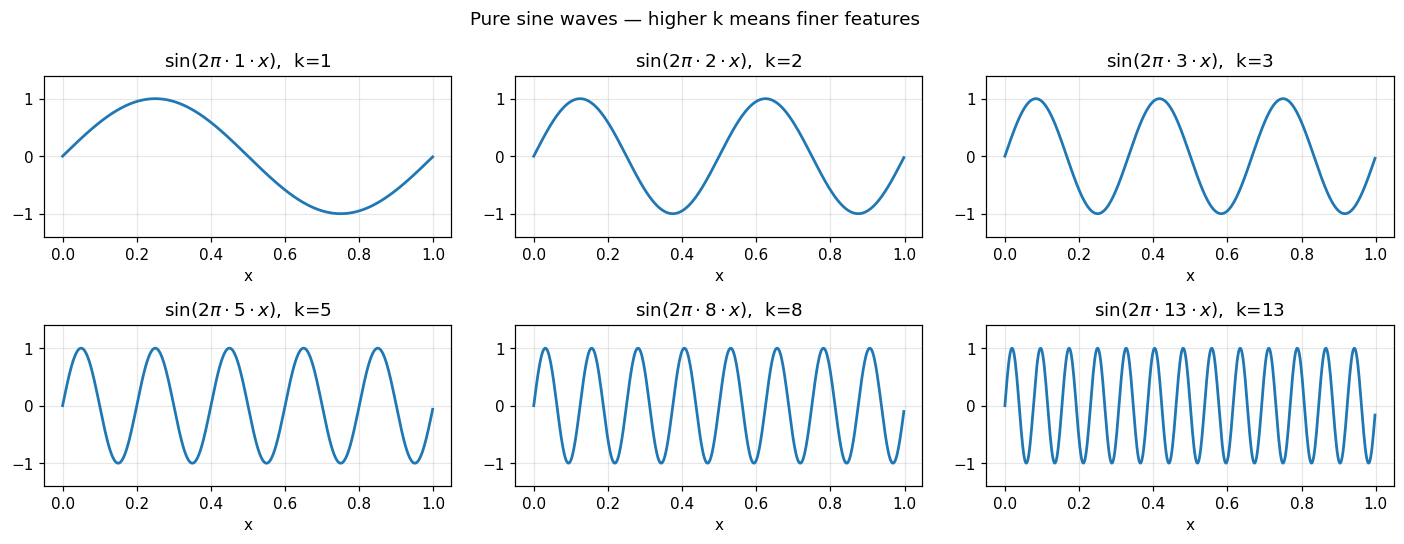

In [2]:
x = np.linspace(0, 1, 500, endpoint=False)

fig, axes = plt.subplots(2, 3, figsize=(13, 5))
for ax, k in zip(axes.ravel(), [1, 2, 3, 5, 8, 13]):
    ax.plot(x, np.sin(2*np.pi*k*x), lw=1.8)
    ax.set_title(f'$\\sin(2\\pi \\cdot {k} \\cdot x)$,  k={k}')
    ax.set_xlabel('x'); ax.set_ylim(-1.4, 1.4)
fig.suptitle('Pure sine waves — higher k means finer features', fontsize=12)
plt.tight_layout(); plt.show()

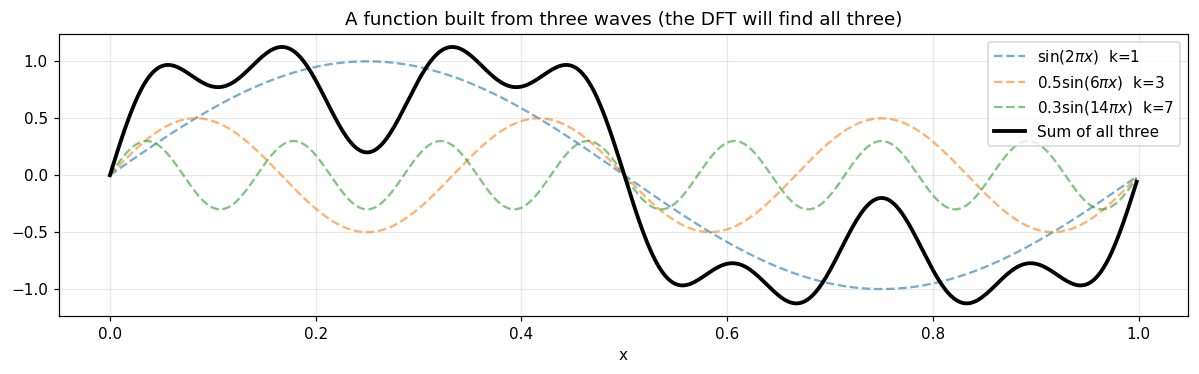

In [3]:
# Any complicated function is a sum of waves.
# The Fourier transform finds which waves are present and how much of each.
f1 = 1.0 * np.sin(2*np.pi*1*x)
f2 = 0.5 * np.sin(2*np.pi*3*x)
f3 = 0.3 * np.sin(2*np.pi*7*x)
f_sum = f1 + f2 + f3

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(x, f1,    '--', alpha=0.6, label='$\\sin(2\\pi x)$  k=1')
ax.plot(x, f2,    '--', alpha=0.6, label='$0.5\\sin(6\\pi x)$  k=3')
ax.plot(x, f3,    '--', alpha=0.6, label='$0.3\\sin(14\\pi x)$  k=7')
ax.plot(x, f_sum, 'k', lw=2.5, label='Sum of all three')
ax.set_xlabel('x'); ax.legend(loc='upper right')
ax.set_title('A function built from three waves (the DFT will find all three)')
plt.tight_layout(); plt.show()

---
## 2  The Fourier Series

Any periodic function $f(x)$ on $[0,1]$ can be written as:
$$f(x) = a_0 + \sum_{k=1}^{\infty}\bigl[a_k\cos(2\pi kx) + b_k\sin(2\pi kx)\bigr]$$

The coefficients $a_k,b_k$ are the Fourier coefficients — they tell you how much
of each frequency is present.

**Classic example:** A square wave requires infinitely many odd harmonics:
$$f(x) = \frac{4}{\pi}\Bigl[\sin(2\pi x) + \tfrac{1}{3}\sin(6\pi x)
+ \tfrac{1}{5}\sin(10\pi x) + \cdots\Bigr]$$
More terms → sharper corners. The infinite series is exact.

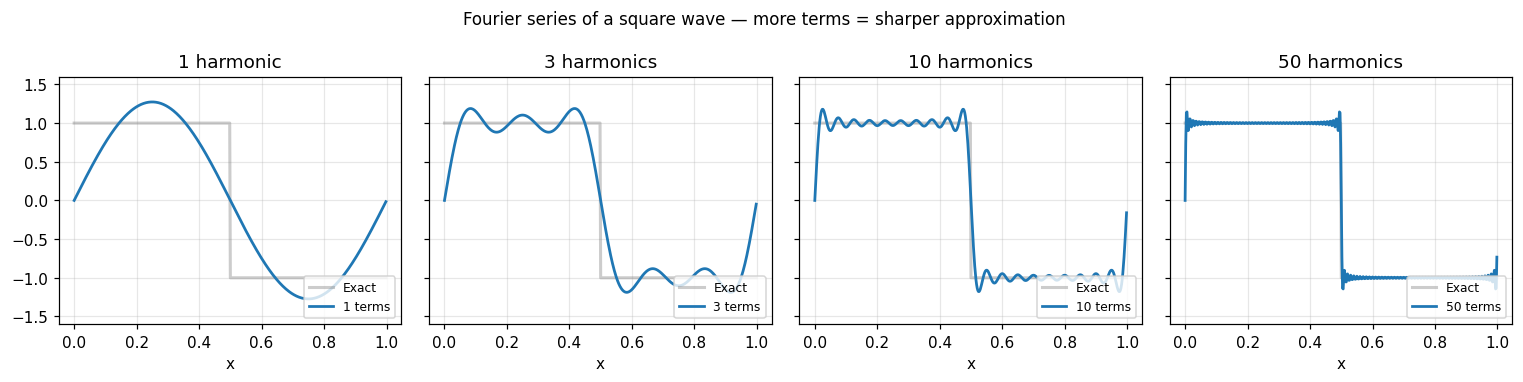

In [4]:
def square_wave(x):
    return np.where((x % 1) < 0.5, 1.0, -1.0)

def fourier_approx_square(x, n_terms):
    result = np.zeros_like(x)
    for i in range(n_terms):
        k = 2*i + 1   # odd harmonics: 1, 3, 5, ...
        result += (4/(np.pi*k)) * np.sin(2*np.pi*k*x)
    return result

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5), sharey=True)
for ax, n in zip(axes, [1, 3, 10, 50]):
    ax.plot(x, square_wave(x), color='gray', lw=2, alpha=0.4, label='Exact')
    ax.plot(x, fourier_approx_square(x, n), 'C0', lw=1.8, label=f'{n} terms')
    ax.set_title(f'{n} harmonic{"s" if n>1 else ""}')
    ax.set_xlabel('x'); ax.legend(loc='lower right', fontsize=8)
    ax.set_ylim(-1.6, 1.6)
fig.suptitle('Fourier series of a square wave — more terms = sharper approximation', fontsize=11)
plt.tight_layout(); plt.show()

---
## 3  The Discrete Fourier Transform (DFT)

Computers work with finite lists of numbers, not continuous functions.
The **DFT** is the discrete version of the Fourier series.

Given $N$ sample values $f[0], \ldots, f[N-1]$ at grid points $x_j = j/N$:

$$\hat{f}[k] = \sum_{j=0}^{N-1} f[j]\, e^{-2\pi i j k/N}, \quad k=0,\ldots,N-1$$

The **inverse DFT** recovers $f$ exactly:
$$f[j] = \frac{1}{N}\sum_{k=0}^{N-1}\hat{f}[k]\, e^{2\pi i jk/N}$$

No information is lost — the DFT is just a change of basis, like rotating a coordinate
system. `numpy.fft.fft` computes this in $O(N\log N)$ operations (the **FFT** algorithm).

In [5]:
def dft_slow(f):
    """Compute DFT by direct summation — O(N²), just for illustration."""
    N = len(f)
    j = np.arange(N)
    k = np.arange(N)
    W = np.exp(-2j*np.pi*np.outer(k, j)/N)   # W[k,j] = e^{-2πijk/N}
    return W @ f

N = 32
x_n = np.arange(N) / N
f_test = np.sin(2*np.pi*3*x_n) + 0.6*np.sin(2*np.pi*7*x_n)

f_hat_slow = dft_slow(f_test)
f_hat_fast = np.fft.fft(f_test)
print(f'Max difference (slow DFT vs NumPy FFT): {np.abs(f_hat_slow - f_hat_fast).max():.2e}')
print('They are identical — the FFT is just a faster algorithm for the same formula.')

Max difference (slow DFT vs NumPy FFT): 8.55e-14
They are identical — the FFT is just a faster algorithm for the same formula.


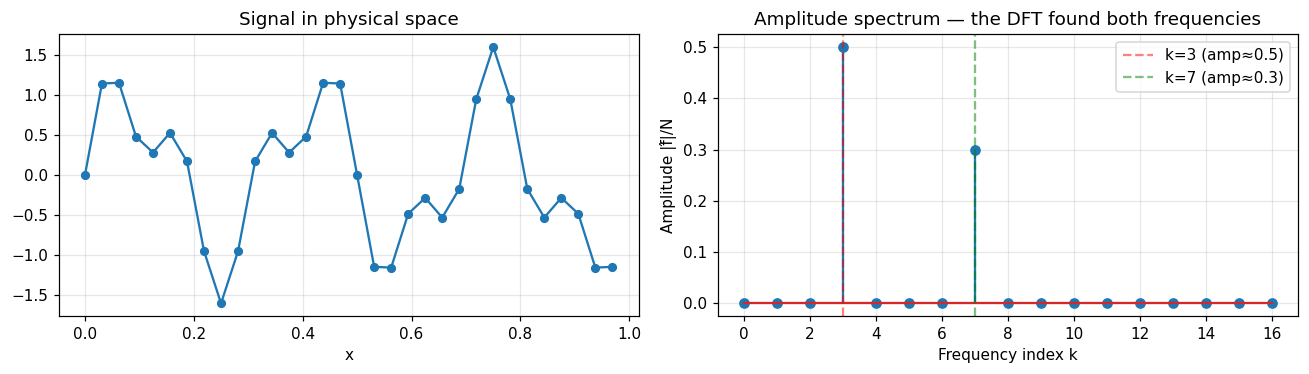

k=3 amplitude: 0.5000  (signal has coefficient 1.0 for sin → 0.5 per-side)
k=7 amplitude: 0.3000  (signal has coefficient 0.6 for sin → 0.3 per-side)


In [6]:
amplitudes = np.abs(f_hat_fast) / N   # normalise to match Fourier series coefficients

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].plot(x_n, f_test, 'o-', ms=5)
axes[0].set_xlabel('x'); axes[0].set_title('Signal in physical space')

axes[1].stem(np.arange(N//2+1), amplitudes[:N//2+1], markerfmt='C0o', linefmt='C0-')
axes[1].axvline(3, color='r', ls='--', alpha=0.5, label='k=3 (amp≈0.5)')
axes[1].axvline(7, color='g', ls='--', alpha=0.5, label='k=7 (amp≈0.3)')
axes[1].set_xlabel('Frequency index k'); axes[1].set_ylabel('Amplitude |f̂|/N')
axes[1].set_title('Amplitude spectrum — the DFT found both frequencies')
axes[1].legend()
plt.tight_layout(); plt.show()

print(f'k=3 amplitude: {amplitudes[3]:.4f}  (signal has coefficient 1.0 for sin → 0.5 per-side)')
print(f'k=7 amplitude: {amplitudes[7]:.4f}  (signal has coefficient 0.6 for sin → 0.3 per-side)')

---
## 4  The FFT and Wavenumber Ordering

NumPy stores the FFT output with a specific ordering. For $N=8$:

| DFT index  | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 |
|---|---|---|---|---|---|---|---|---|
| Wavenumber | 0 | 1 | 2 | 3 | ±4 | −3 | −2 | −1 |

Indices above $N/2$ correspond to **negative frequencies** — they are the complex
conjugates of the positive ones (for real-valued signals).

The centred wavenumber is: $k_\text{eff}[j] = j - N\cdot\mathbf{1}[j > N/2]$

```python
k_eff = k - N * (k > N//2)
```

In [7]:
N = 16
k_raw = np.arange(N)
k_eff = (k_raw - N*(k_raw > N//2)).astype(float)

print('DFT index:', k_raw)
print('k_eff:    ', k_eff.astype(int))
print()
print(f'DC mode   → index 0    → k = 0      (constant, mean of f)')
print(f'Nyquist   → index {N//2}   → k = ±{N//2}   (highest representable freq)')
print(f'Neg freqs → index {N//2+1}-{N-1} → k = {k_eff[N//2+1:].astype(int)}')

DFT index: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15]
k_eff:     [ 0  1  2  3  4  5  6  7  8 -7 -6 -5 -4 -3 -2 -1]

DC mode   → index 0    → k = 0      (constant, mean of f)
Nyquist   → index 8   → k = ±8   (highest representable freq)
Neg freqs → index 9-15 → k = [-7 -6 -5 -4 -3 -2 -1]


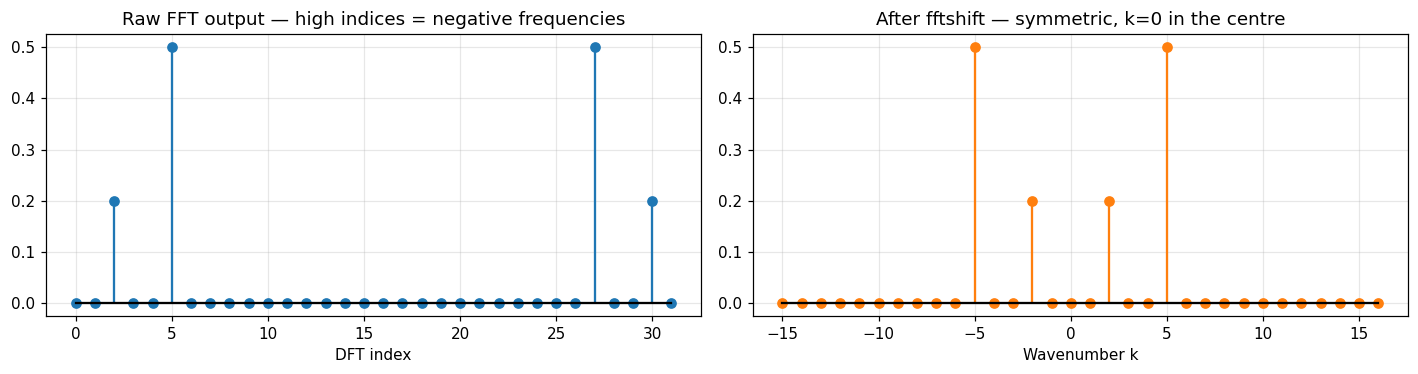

In [8]:
# np.fft.fftshift rearranges so k=0 is at the centre (useful for plotting)
N = 32; x_n = np.arange(N)/N
f_demo = np.sin(2*np.pi*5*x_n) + 0.4*np.cos(2*np.pi*2*x_n)
f_hat  = np.fft.fft(f_demo)
k_eff2 = np.arange(N) - N*(np.arange(N) > N//2)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
axes[0].stem(np.arange(N), np.abs(f_hat)/N, markerfmt='C0o', linefmt='C0-', basefmt='k-')
axes[0].set_xlabel('DFT index')
axes[0].set_title('Raw FFT output — high indices = negative frequencies')

axes[1].stem(np.fft.fftshift(k_eff2), np.fft.fftshift(np.abs(f_hat)/N),
             markerfmt='C1o', linefmt='C1-', basefmt='k-')
axes[1].set_xlabel('Wavenumber k')
axes[1].set_title('After fftshift — symmetric, k=0 in the centre')
plt.tight_layout(); plt.show()

---
## 5  The Nyquist Frequency and Aliasing

The highest frequency representable on a grid of $N$ points is $k_\text{Nyquist} = N/2$.
If a function has frequencies higher than $N/2$, the DFT **cannot represent them**
— they get folded back and appear as lower-frequency content. This is **aliasing**.

**Analogy:** A camera at 24 fps cannot capture motion faster than 12 cycles/second.
A car wheel spinning too fast appears to rotate backwards — that is aliasing.

**The Nyquist mode at $k=N/2$** is ambiguous for *first derivatives*:
$+N/2$ and $-N/2$ give opposite-sign derivatives on the grid.
We zero it out: `k_d[N//2] = 0`. For the Laplacian ($k^2$), both signs agree — no zeroing needed.

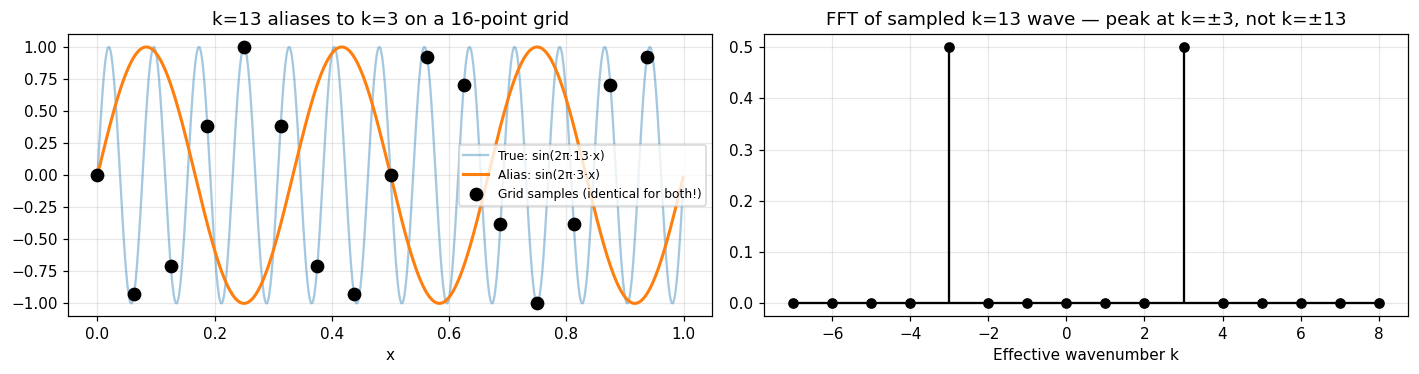

Nyquist for N=16: k_max = 8. k=13 > 8 aliases to k=-3.


In [9]:
N = 16
x_grid = np.arange(N) / N
x_fine = np.linspace(0, 1, 1000, endpoint=False)

k_true  = 13     # above Nyquist (N/2 = 8)
k_alias = k_true - N  # = -3  (wraps to -3, same magnitude as k=3)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
axes[0].plot(x_fine, np.sin(2*np.pi*k_true*x_fine), 'C0', alpha=0.4,
             label=f'True: sin(2π·{k_true}·x)')
axes[0].plot(x_fine, np.sin(2*np.pi*abs(k_alias)*x_fine), 'C1', lw=2,
             label=f'Alias: sin(2π·{abs(k_alias)}·x)')
axes[0].plot(x_grid, np.sin(2*np.pi*k_true*x_grid), 'ko', ms=8, zorder=5,
             label='Grid samples (identical for both!)')
axes[0].set_xlabel('x')
axes[0].set_title(f'k={k_true} aliases to k={abs(k_alias)} on a {N}-point grid')
axes[0].legend(fontsize=8)

f_coarse = np.sin(2*np.pi*k_true*x_grid)
f_hat_c  = np.fft.fft(f_coarse)
k_eff_c  = np.arange(N) - N*(np.arange(N) > N//2)
axes[1].stem(k_eff_c, np.abs(f_hat_c)/N, markerfmt='ko', linefmt='k-', basefmt='k-')
axes[1].set_xlabel('Effective wavenumber k')
axes[1].set_title(f'FFT of sampled k={k_true} wave — peak at k=±{abs(k_alias)}, not k=±{k_true}')
plt.tight_layout(); plt.show()
print(f'Nyquist for N={N}: k_max = {N//2}. k={k_true} > {N//2} aliases to k={k_alias}.')

---
## 6  Spectral Differentiation in 1D — The Core Magic Trick

If $f(x) = \sum_k \hat{f}(k)\,e^{2\pi ikx}$, then taking the derivative:
$$\frac{df}{dx} = \sum_k \hat{f}(k)\cdot(2\pi ik)\,e^{2\pi ikx}$$

**Differentiation in physical space = multiply by $2\pi ik$ in Fourier space.**

Recipe:
1. $\hat{f} = \text{FFT}(f)$
2. $\widehat{df/dx}[k] = (2\pi ik)\,\hat{f}[k]$
3. $df/dx = \text{real}(\text{IFFT}(\widehat{df/dx}))$

Spectral derivatives are **exponentially accurate** for smooth functions —
far better than finite differences.

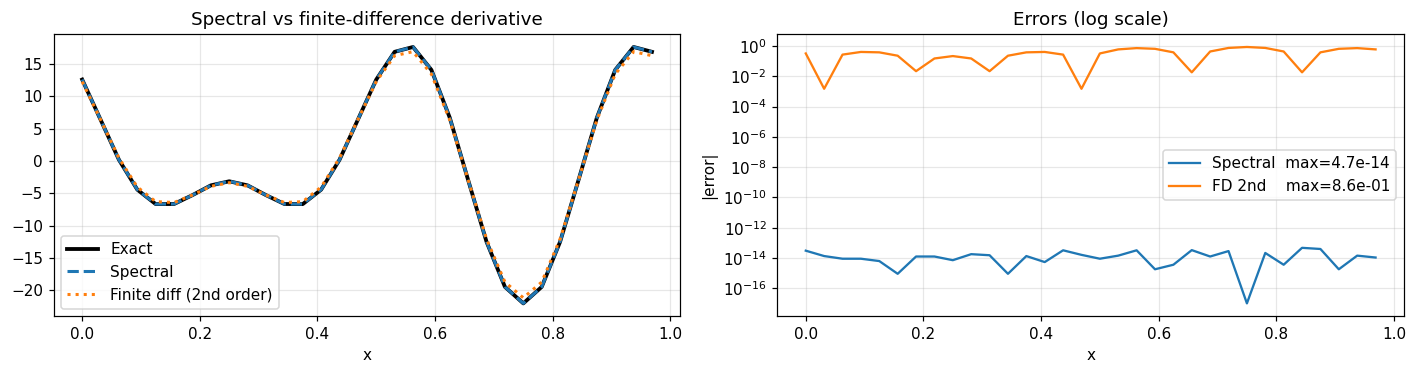

Spectral: near machine precision. Finite diff: O(dx²) error.


In [10]:
N = 32; x_n = np.arange(N)/N
f_test   = np.sin(2*np.pi*2*x_n) + 0.5*np.cos(2*np.pi*3*x_n)
df_exact = 2*np.pi*2*np.cos(2*np.pi*2*x_n) - 0.5*2*np.pi*3*np.sin(2*np.pi*3*x_n)

k_raw = np.arange(N)
k_eff = (k_raw - N*(k_raw > N//2)).astype(float)
k_d   = k_eff.copy(); k_d[N//2] = 0.0   # zero Nyquist

# Spectral derivative
df_spec = np.real(np.fft.ifft((2j*np.pi*k_d) * np.fft.fft(f_test)))

# 2nd-order finite difference for comparison
dx = 1.0/N
df_fd = (np.roll(f_test, -1) - np.roll(f_test, 1)) / (2*dx)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
axes[0].plot(x_n, df_exact, 'k', lw=2.5, label='Exact')
axes[0].plot(x_n, df_spec,  'C0--', lw=2, label='Spectral')
axes[0].plot(x_n, df_fd,    'C1:', lw=2, label='Finite diff (2nd order)')
axes[0].set_xlabel('x'); axes[0].legend()
axes[0].set_title('Spectral vs finite-difference derivative')

err_spec = np.abs(df_spec - df_exact)
err_fd   = np.abs(df_fd - df_exact)
axes[1].semilogy(x_n, err_spec+1e-17, 'C0', label=f'Spectral  max={err_spec.max():.1e}')
axes[1].semilogy(x_n, err_fd+1e-17,   'C1', label=f'FD 2nd    max={err_fd.max():.1e}')
axes[1].set_xlabel('x'); axes[1].set_ylabel('|error|')
axes[1].set_title('Errors (log scale)')
axes[1].legend()
plt.tight_layout(); plt.show()
print('Spectral: near machine precision. Finite diff: O(dx²) error.')

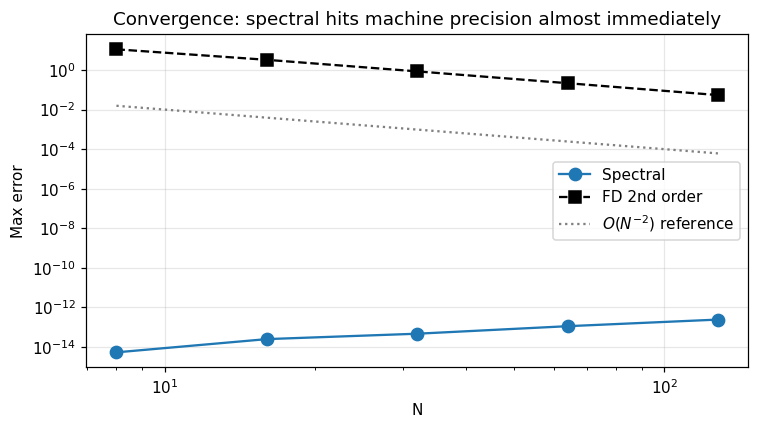

In [11]:
# Convergence: how does the error shrink as N grows?
Ns = [8, 16, 32, 64, 128]
err_s, err_f = [], []
for N_ in Ns:
    x_  = np.arange(N_)/N_
    f_  = np.sin(2*np.pi*2*x_) + 0.5*np.cos(2*np.pi*3*x_)
    dfe = 2*np.pi*2*np.cos(2*np.pi*2*x_) - 0.5*2*np.pi*3*np.sin(2*np.pi*3*x_)
    k_  = np.arange(N_); k_ = (k_ - N_*(k_ > N_//2)).astype(float); k_[N_//2] = 0
    dfs = np.real(np.fft.ifft((2j*np.pi*k_)*np.fft.fft(f_)))
    dff = (np.roll(f_,-1) - np.roll(f_,1)) / (2/N_)
    err_s.append(np.abs(dfs-dfe).max())
    err_f.append(np.abs(dff-dfe).max())

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(Ns, err_s, 'C0o-', ms=8, label='Spectral')
ax.loglog(Ns, err_f, 'ks--', ms=8, label='FD 2nd order')
ax.loglog(Ns, [1/n**2 for n in Ns], color='gray', ls=':', label='$O(N^{-2})$ reference')
ax.set_xlabel('N'); ax.set_ylabel('Max error'); ax.legend()
ax.set_title('Convergence: spectral hits machine precision almost immediately')
plt.tight_layout(); plt.show()

---
## 7  The 2D DFT

For a 2D function $f(x,y)$ on an $N\times N$ grid, the DFT is applied
independently in both spatial directions:
$$\hat{f}[k_y,k_x] = \sum_{i=0}^{N-1}\sum_{j=0}^{N-1}f[i,j]\,e^{-2\pi i(ik_y+jk_x)/N}$$

**Convention in the mixing code (and NumPy):**
- Row index $i$ → $y$-direction, wavenumber $k_y$
- Column index $j$ → $x$-direction, wavenumber $k_x$

`DEL_X` has shape `(1,N)` (acts on columns = $x$-direction) and
`DEL_Y` has shape `(N,1)` (acts on rows = $y$-direction).
NumPy broadcasting handles the rest — no need to store $N\times N$ matrices.

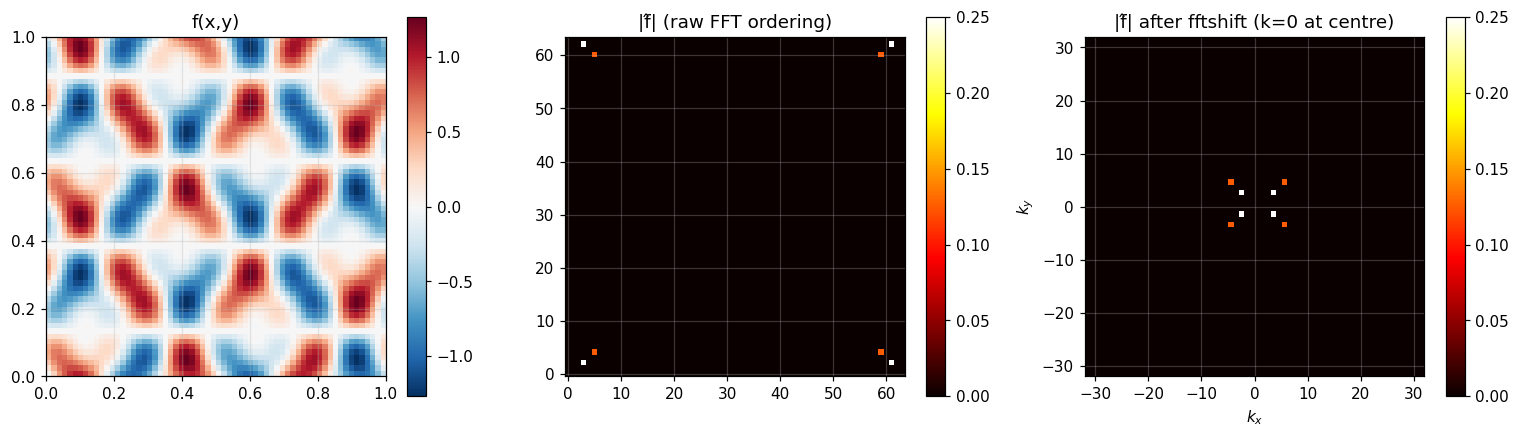

In [12]:
N = 64; dx = 1/N; x = np.arange(N)*dx
xx, yy = np.meshgrid(x, x)

f2d = np.sin(2*np.pi*3*xx)*np.cos(2*np.pi*2*yy) + 0.5*np.cos(2*np.pi*5*xx)*np.sin(2*np.pi*4*yy)
f2d_hat = np.fft.fft2(f2d)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
im0 = axes[0].imshow(f2d, origin='lower', extent=[0,1,0,1], cmap='RdBu_r', aspect='equal')
axes[0].set_title('f(x,y)'); plt.colorbar(im0, ax=axes[0])

amp = np.abs(f2d_hat)/N**2
im1 = axes[1].imshow(amp, origin='lower', cmap='hot')
axes[1].set_title('|f̂| (raw FFT ordering)')
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(np.fft.fftshift(amp), origin='lower',
                     extent=[-N//2,N//2,-N//2,N//2], cmap='hot')
axes[2].set_title('|f̂| after fftshift (k=0 at centre)')
axes[2].set_xlabel('$k_x$'); axes[2].set_ylabel('$k_y$')
plt.colorbar(im2, ax=axes[2])
plt.tight_layout(); plt.show()

In [13]:
# Build the 2D derivative operators
k_raw = np.arange(N); k_eff = (k_raw - N*(k_raw > N//2)).astype(float)
k_d   = k_eff.copy(); k_d[N//2] = 0.0
DEL_X = (2j*np.pi*k_d)[np.newaxis, :]   # shape (1, N) — x-direction
DEL_Y = (2j*np.pi*k_d)[:, np.newaxis]   # shape (N, 1) — y-direction

print(f'DEL_X shape: {DEL_X.shape}  →  broadcasts over rows (acts on columns, x-direction)')
print(f'DEL_Y shape: {DEL_Y.shape}  →  broadcasts over cols  (acts on rows,    y-direction)')

# Spectral derivatives
df_dx_spec = np.real(np.fft.ifft2(DEL_X * f2d_hat))
df_dy_spec = np.real(np.fft.ifft2(DEL_Y * f2d_hat))

# Exact
df_dx_exact = (2*np.pi*3*np.cos(2*np.pi*3*xx)*np.cos(2*np.pi*2*yy)
               - 0.5*2*np.pi*5*np.sin(2*np.pi*5*xx)*np.sin(2*np.pi*4*yy))

err_x = np.abs(df_dx_spec - df_dx_exact).max()
print(f'\n‖∂f/∂x spectral - exact‖∞ = {err_x:.2e}  (near machine precision)')

DEL_X shape: (1, 64)  →  broadcasts over rows (acts on columns, x-direction)
DEL_Y shape: (64, 1)  →  broadcasts over cols  (acts on rows,    y-direction)

‖∂f/∂x spectral - exact‖∞ = 1.95e-13  (near machine precision)


---
## 8  The Laplacian and Its Inverse

The Laplacian $\Delta f = \partial_{xx}f + \partial_{yy}f$ in Fourier space is:
$$\widehat{\Delta f}[k_y,k_x] = \bigl[(2\pi ik_x)^2+(2\pi ik_y)^2\bigr]\hat{f}
= -4\pi^2|k|^2\,\hat{f}$$

The **inverse Laplacian** $\Delta^{-1}$ multiplies by:
$$\text{LAP\_INV}[k_y,k_x] = \frac{-1}{(2\pi)^2(k_x^2+k_y^2)}, \quad
\text{LAP\_INV}[0,0] = 0$$

The DC mode $k=(0,0)$ is set to zero (otherwise we divide by zero; the spatial
mean of $\theta$ is separately conserved and excluded from the dynamics).

**Physical intuition:** $\Delta^{-1}$ *smooths*. Fine-scale (high-$k$) features
are suppressed more than coarse ones.

LAP_INV is real (imaginary part ≈ 0): True
LAP_INV is non-positive:               True
LAP_INV[0,0] = 0j  (DC excluded)
LAP_INV[0,1] = -0.02533030,  expected = -0.02533030


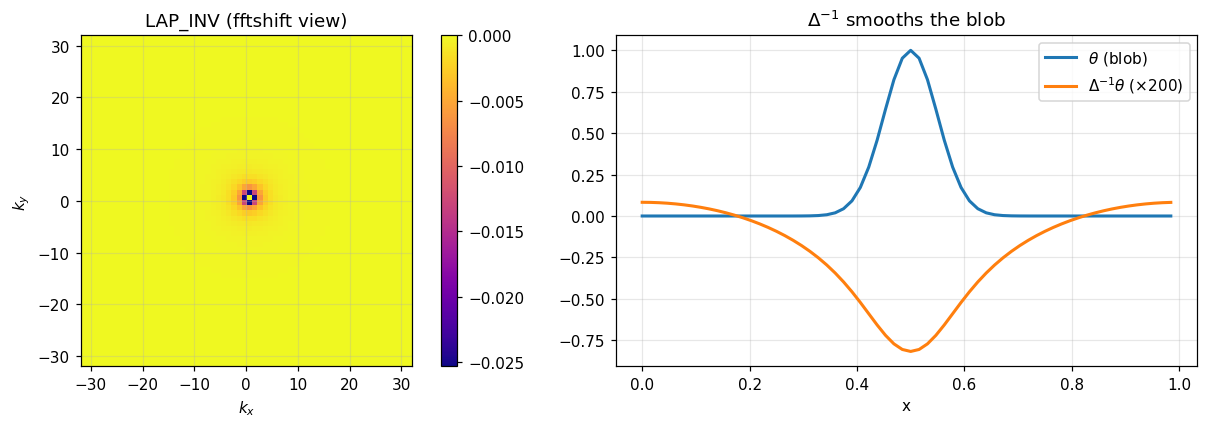

In [14]:
N = 64; dx = 1/N; x = np.arange(N)*dx; xx,yy = np.meshgrid(x,x)
k_raw = np.arange(N); k_eff = (k_raw - N*(k_raw > N//2)).astype(float)
kx = (2j*np.pi*k_eff)[np.newaxis,:]; ky = (2j*np.pi*k_eff)[:,np.newaxis]
lap = kx**2 + ky**2

LAP_INV = np.zeros_like(lap)
nz = lap != 0
LAP_INV[nz] = 1.0 / lap[nz]

print(f'LAP_INV is real (imaginary part ≈ 0): {np.allclose(LAP_INV.imag, 0)}')
print(f'LAP_INV is non-positive:               {(LAP_INV.real <= 1e-10).all()}')
print(f'LAP_INV[0,0] = {LAP_INV[0,0]}  (DC excluded)')
print(f'LAP_INV[0,1] = {LAP_INV[0,1].real:.8f},  expected = {-1/(4*np.pi**2):.8f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
im0 = axes[0].imshow(np.fft.fftshift(LAP_INV.real), cmap='plasma',
                     extent=[-N//2,N//2,-N//2,N//2], origin='lower')
axes[0].set_title('LAP_INV (fftshift view)'); plt.colorbar(im0, ax=axes[0])
axes[0].set_xlabel('$k_x$'); axes[0].set_ylabel('$k_y$')

blob = np.exp(-200*((xx-0.5)**2+(yy-0.5)**2))
blob_smooth = np.real(np.fft.ifft2(LAP_INV * np.fft.fft2(blob)))
axes[1].plot(x, blob[N//2,:], 'C0', lw=2, label='$\\theta$ (blob)')
axes[1].plot(x, blob_smooth[N//2,:]*200, 'C1', lw=2, label='$\\Delta^{-1}\\theta$ (×200)')
axes[1].set_xlabel('x'); axes[1].set_title('$\\Delta^{-1}$ smooths the blob')
axes[1].legend()
plt.tight_layout(); plt.show()

In [15]:
# Verify: Δ(Δ⁻¹θ) = θ  (for zero-mean θ)
theta_test = np.sin(2*np.pi*3*xx)*np.cos(2*np.pi*2*yy)
theta_hat  = np.fft.fft2(theta_test)
recovered  = np.real(np.fft.ifft2(lap * LAP_INV * theta_hat))
print(f'‖Δ(Δ⁻¹θ) - θ‖∞ = {np.abs(recovered - theta_test).max():.2e}  (machine precision)')

‖Δ(Δ⁻¹θ) - θ‖∞ = 4.44e-16  (machine precision)


---
## 9  Parseval's Identity — Norms in Fourier Space

Parseval's identity: **the Fourier transform preserves the total energy (sum of squares)**.

For 2D with $N^2$ grid points:
$$\|f\|_{L^2}^2 \approx \frac{\|\hat{f}\|_{\ell^2}^2}{N^4}
\quad\Longrightarrow\quad
\|f\|_{L^2} \approx \frac{\|\hat{f}\|_{\ell^2}}{N^2}$$

This means we can compute norms **entirely in Fourier space** without transforming back.
This is used in the mixing code to compute $\|\nabla v\|_{L^2}$ (the enstrophy) for the
velocity normalisation step.

In [16]:
N = 64; dx = 1/N; x = np.arange(N)*dx; xx,yy = np.meshgrid(x,x)

# f = sin(2πx)sin(2πy)  has exact L2 norm = 1/2
f = np.sin(2*np.pi*xx) * np.sin(2*np.pi*yy)
f_hat = np.fft.fft2(f)

norm_physical = np.sqrt(np.sum(f**2) * dx**2)
norm_parseval = np.sqrt(np.sum(np.abs(f_hat)**2)) / N**2

print(f'Exact L2 norm:          0.5')
print(f'Physical space method:  {norm_physical:.8f}')
print(f'Parseval (Fourier):     {norm_parseval:.8f}')
print(f'Difference:             {abs(norm_physical - norm_parseval):.2e}')
print()
print('In the mixing code, ||∇v||_{L2} is computed via Parseval:')
print('  ||∇v||_{L2}² = (1/N²)² × (||DEL_X * vx_hat||² + ||DEL_Y * vx_hat||² + ...)')
print('This avoids a costly IFFT just to compute a scalar number.')

Exact L2 norm:          0.5
Physical space method:  0.50000000
Parseval (Fourier):     0.50000000
Difference:             0.00e+00

In the mixing code, ||∇v||_{L2} is computed via Parseval:
  ||∇v||_{L2}² = (1/N²)² × (||DEL_X * vx_hat||² + ||DEL_Y * vx_hat||² + ...)
This avoids a costly IFFT just to compute a scalar number.


---
## 10  The $H^{-1}$ Mix Norm

Under $\partial_t\theta + u\cdot\nabla\theta = 0$ with divergence-free $u$,
all $L^p$ norms are **conserved** — the $L^2$ norm stays constant, so it cannot
detect mixing.

The **$H^{-1}$ norm** down-weights fine-scale content:
$$\|\theta\|_{H^{-1}}^2 = \sum_{k\neq 0}\frac{|\hat\theta(k)|^2}{4\pi^2|k|^2}$$

As stirring moves energy from low $k$ to high $k$, the norm decreases — because
high-$k$ modes count for less (divided by the large $|k|^2$).

In code: `LAMBDA_INV = sqrt(-LAP_INV)` = $1/(2\pi|k|)$ and
$\|\theta\|_{H^{-1}}^2 = \|\text{LAMBDA\_INV}\cdot\hat\theta\|^2/N^4$.

In [17]:
LAMBDA_INV = np.sqrt(np.where(LAP_INV.real < 0, -LAP_INV.real, 0.0))

def hm1_norm(f, LAMBDA_INV, N):
    return np.sqrt(np.sum(np.abs(LAMBDA_INV * np.fft.fft2(f))**2)) / N**2

def l2_norm(f, dx):
    return np.sqrt(np.sum(f**2)*dx**2)

# Three fields — same L2 norm, different H^{-1} norms
f_low  = np.sin(2*np.pi*1*xx)*np.sin(2*np.pi*1*yy)
f_med  = np.sin(2*np.pi*4*xx)*np.sin(2*np.pi*4*yy)
f_high = np.sin(2*np.pi*10*xx)*np.sin(2*np.pi*10*yy)

for f in [f_low, f_med, f_high]:   # L2-normalise each
    f /= l2_norm(f, dx)

print(f'{"Field":<20}  {"L2 norm":>10}  {"H^{-1} norm":>12}')
print('-'*46)
for name, f in [("Low freq (k=1)", f_low), ("Med freq (k=4)", f_med), ("High freq (k=10)", f_high)]:
    print(f'{name:<20}  {l2_norm(f, dx):>10.4f}  {hm1_norm(f, LAMBDA_INV, N):>12.6f}')
print()
print('All have L2 norm = 1, but the H^{-1} norm is smallest for fine-scale fields.')
print('Mixing moves energy to higher k → H^{-1} norm decreases.')

Field                    L2 norm   H^{-1} norm
----------------------------------------------
Low freq (k=1)            1.0000      0.112540
Med freq (k=4)            1.0000      0.028135
High freq (k=10)          1.0000      0.011254

All have L2 norm = 1, but the H^{-1} norm is smallest for fine-scale fields.
Mixing moves energy to higher k → H^{-1} norm decreases.


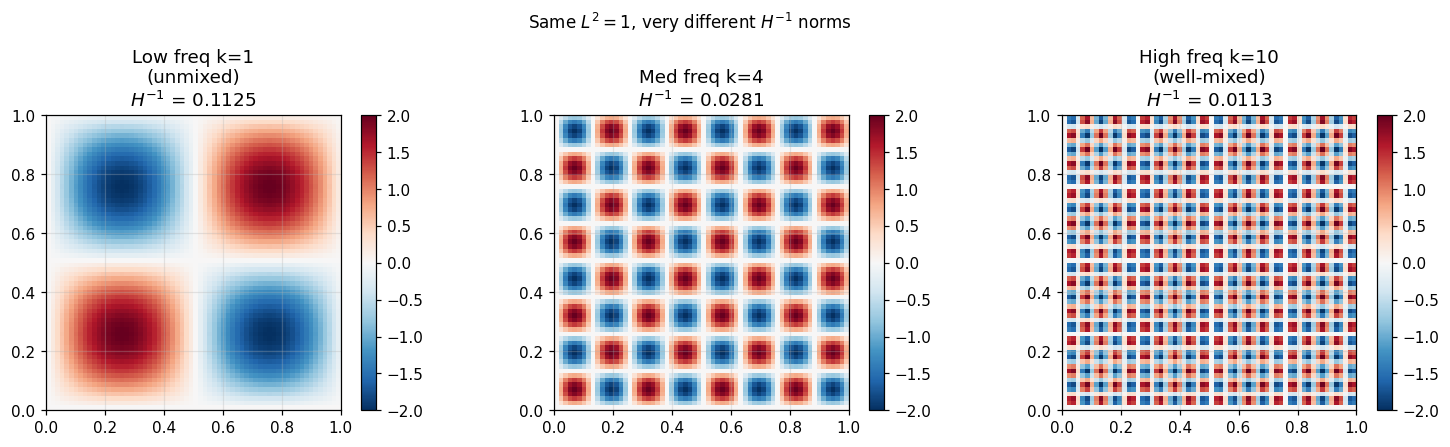

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fields = [("Low freq k=1\n(unmixed)", f_low), ("Med freq k=4", f_med), ("High freq k=10\n(well-mixed)", f_high)]
for ax, (name, f) in zip(axes, fields):
    vmax = np.abs(f).max()
    im = ax.imshow(f, origin='lower', extent=[0,1,0,1], cmap='RdBu_r',
                   vmin=-vmax, vmax=vmax, aspect='equal')
    ax.set_title(f'{name}\n$H^{{-1}}$ = {hm1_norm(f, LAMBDA_INV, N):.4f}')
    plt.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle('Same $L^2 = 1$, very different $H^{-1}$ norms', fontsize=11)
plt.tight_layout(); plt.show()

---
## 11  The Leray Projection — Enforcing Incompressibility

The velocity must satisfy $\nabla\cdot u = 0$ (incompressibility — no sources or sinks).

The **Leray projection** $Pg$ extracts the divergence-free part of any vector field $g$:
$$Pg = g - \nabla\Delta^{-1}(\nabla\cdot g)$$

- Step 1: compute divergence $D = \nabla\cdot g$
- Step 2: scalar potential $\phi = \Delta^{-1}D$ (contains all the divergence)
- Step 3: subtract $\nabla\phi$ to remove it: $Pg = g - \nabla\phi$

In Fourier space this is **just element-wise multiplication** — no system to solve.

In [19]:
N = 64; dx = 1/N; x = np.arange(N)*dx; xx,yy = np.meshgrid(x,x)
k_raw = np.arange(N); k_eff = (k_raw - N*(k_raw > N//2)).astype(float)
k_d = k_eff.copy(); k_d[N//2] = 0.0
DEL_X_ = (2j*np.pi*k_d)[np.newaxis,:]; DEL_Y_ = (2j*np.pi*k_d)[:,np.newaxis]
kx_ = (2j*np.pi*k_eff)[np.newaxis,:]; ky_ = (2j*np.pi*k_eff)[:,np.newaxis]
lap_ = kx_**2 + ky_**2
LAP_INV_ = np.where(lap_ != 0, 1.0/lap_, 0.0)

def leray(gx, gy, DEL_X, DEL_Y, LAP_INV):
    gxh = np.fft.fft2(gx); gyh = np.fft.fft2(gy)
    div = DEL_X*gxh + DEL_Y*gyh
    Pgxh = gxh - DEL_X*LAP_INV*div
    Pgyh = gyh - DEL_Y*LAP_INV*div
    return np.real(np.fft.ifft2(Pgxh)), np.real(np.fft.ifft2(Pgyh))

def div_norm(ux, uy, DEL_X, DEL_Y):
    return np.abs(np.real(np.fft.ifft2(DEL_X*np.fft.fft2(ux) + DEL_Y*np.fft.fft2(uy)))).max()

gx = np.cos(2*np.pi*2*xx)*np.cos(2*np.pi*1*yy)
gy = np.sin(2*np.pi*3*xx) + 0.5*np.sin(2*np.pi*2*yy)
Pgx, Pgy = leray(gx, gy, DEL_X_, DEL_Y_, LAP_INV_)

print(f'‖∇·g‖∞  before Leray: {div_norm(gx, gy, DEL_X_, DEL_Y_):.4f}')
print(f'‖∇·Pg‖∞ after  Leray: {div_norm(Pgx, Pgy, DEL_X_, DEL_Y_):.2e}')
print('After projection the field is divergence-free to machine precision.')

‖∇·g‖∞  before Leray: 18.8496
‖∇·Pg‖∞ after  Leray: 3.42e-14
After projection the field is divergence-free to machine precision.


/var/folders/vw/cvpzngmd70n3c6kcq2p9ck780000gn/T/ipykernel_62715/2882393670.py:7: RuntimeWarning: divide by zero encountered in divide
  LAP_INV_ = np.where(lap_ != 0, 1.0/lap_, 0.0)
/var/folders/vw/cvpzngmd70n3c6kcq2p9ck780000gn/T/ipykernel_62715/2882393670.py:7: RuntimeWarning: invalid value encountered in divide
  LAP_INV_ = np.where(lap_ != 0, 1.0/lap_, 0.0)


---
## 12  The Pseudo-Spectral Method — Putting It All Together

We now have all the tools. Let us implement one full RHS evaluation for the mixing equation.

**Why pseudo-spectral?** The term $\theta\cdot\nabla\Delta^{-1}\theta$ is a *product* of
two fields. In Fourier space, products become convolutions ($O(N^4)$ cost). Instead:

1. Transform needed quantities to physical space (IFFT)
2. Compute the product pointwise (cheap array multiplication)
3. Transform back (FFT)

**The 5-step RHS pipeline:**
1. Compute $g = \theta\nabla\Delta^{-1}\theta$ (pseudo-spectral product)
2. Leray project $g$ → divergence-free $Pg$
3. Apply $-\Delta^{-1}$ → velocity $v$
4. Normalise $v$ by $\|\nabla v\|_{L^2}$ (Parseval) → $u$
5. Advect: $d\hat\theta/dt = -\mathcal{F}[u\cdot\nabla\theta]$

In [20]:
# Build operators for N=32
N = 32; dx = 1/N; x = np.arange(N)*dx; xx,yy = np.meshgrid(x,x)
k_raw = np.arange(N); k_eff = (k_raw - N*(k_raw > N//2)).astype(float)
k_d   = k_eff.copy(); k_d[N//2] = 0.0
DEL_X = (2j*np.pi*k_d)[np.newaxis,:]; DEL_Y = (2j*np.pi*k_d)[:,np.newaxis]
kx2 = (2j*np.pi*k_eff)[np.newaxis,:]; ky2 = (2j*np.pi*k_eff)[:,np.newaxis]
lap2 = kx2**2 + ky2**2
LAP_INV2 = np.where(lap2 != 0, 1.0/lap2, 0.0)
LAMBDA_INV2 = np.sqrt(np.where(LAP_INV2.real < 0, -LAP_INV2.real, 0.0))

def compute_rhs(theta, DEL_X, DEL_Y, LAP_INV, N, F=1.0):
    theta_hat = np.fft.fft2(theta)

    # Step 1: g = theta * nabla(Δ⁻¹θ)  [pseudo-spectral]
    psi_hat  = LAP_INV * theta_hat
    dpsi_dx  = np.real(np.fft.ifft2(DEL_X * psi_hat))
    dpsi_dy  = np.real(np.fft.ifft2(DEL_Y * psi_hat))
    gx_hat   = np.fft.fft2(theta * dpsi_dx)
    gy_hat   = np.fft.fft2(theta * dpsi_dy)

    # Step 2: Leray projection
    div_hat  = DEL_X*gx_hat + DEL_Y*gy_hat
    Pgx_hat  = gx_hat - DEL_X*LAP_INV*div_hat
    Pgy_hat  = gy_hat - DEL_Y*LAP_INV*div_hat

    # Step 3: v = -Δ⁻¹ Pg
    vx_hat = -LAP_INV * Pgx_hat
    vy_hat = -LAP_INV * Pgy_hat

    # Step 4: normalise by ||∇v||_{L2} (Parseval)
    c = (1/N**2)**2
    grad_norm = np.sqrt(c*(
        np.sum(np.abs(DEL_X*vx_hat)**2) + np.sum(np.abs(DEL_Y*vx_hat)**2) +
        np.sum(np.abs(DEL_X*vy_hat)**2) + np.sum(np.abs(DEL_Y*vy_hat)**2)))
    ux_hat = F/grad_norm * vx_hat
    uy_hat = F/grad_norm * vy_hat

    # Step 5: advect  dθ/dt = -(u·∇)θ
    ux = np.real(np.fft.ifft2(ux_hat)); uy = np.real(np.fft.ifft2(uy_hat))
    dtdx = np.real(np.fft.ifft2(DEL_X*theta_hat))
    dtdy = np.real(np.fft.ifft2(DEL_Y*theta_hat))
    rhs_hat = np.fft.fft2(-(ux*dtdx + uy*dtdy))
    return rhs_hat, ux, uy

# Initial blob
theta0 = np.exp(-100*((xx-0.5)**2 + (yy-0.5)**2))
theta0 /= np.sqrt(np.sum(theta0**2))*dx

rhs_hat, ux, uy = compute_rhs(theta0, DEL_X, DEL_Y, LAP_INV2, N)
rhs = np.real(np.fft.ifft2(rhs_hat))

# Verify enstrophy constraint
c = (1/N**2)**2
uh, vh = np.fft.fft2(ux), np.fft.fft2(uy)
enstrophy = np.sqrt(c*(np.sum(np.abs(DEL_X*uh)**2)+np.sum(np.abs(DEL_Y*uh)**2)
                      +np.sum(np.abs(DEL_X*vh)**2)+np.sum(np.abs(DEL_Y*vh)**2)))
print(f'||∇u||_L2 = {enstrophy:.10f}   (should be exactly F = 1.0)')

||∇u||_L2 = 1.0000000000   (should be exactly F = 1.0)


/var/folders/vw/cvpzngmd70n3c6kcq2p9ck780000gn/T/ipykernel_62715/2063240942.py:8: RuntimeWarning: divide by zero encountered in divide
  LAP_INV2 = np.where(lap2 != 0, 1.0/lap2, 0.0)
/var/folders/vw/cvpzngmd70n3c6kcq2p9ck780000gn/T/ipykernel_62715/2063240942.py:8: RuntimeWarning: invalid value encountered in divide
  LAP_INV2 = np.where(lap2 != 0, 1.0/lap2, 0.0)


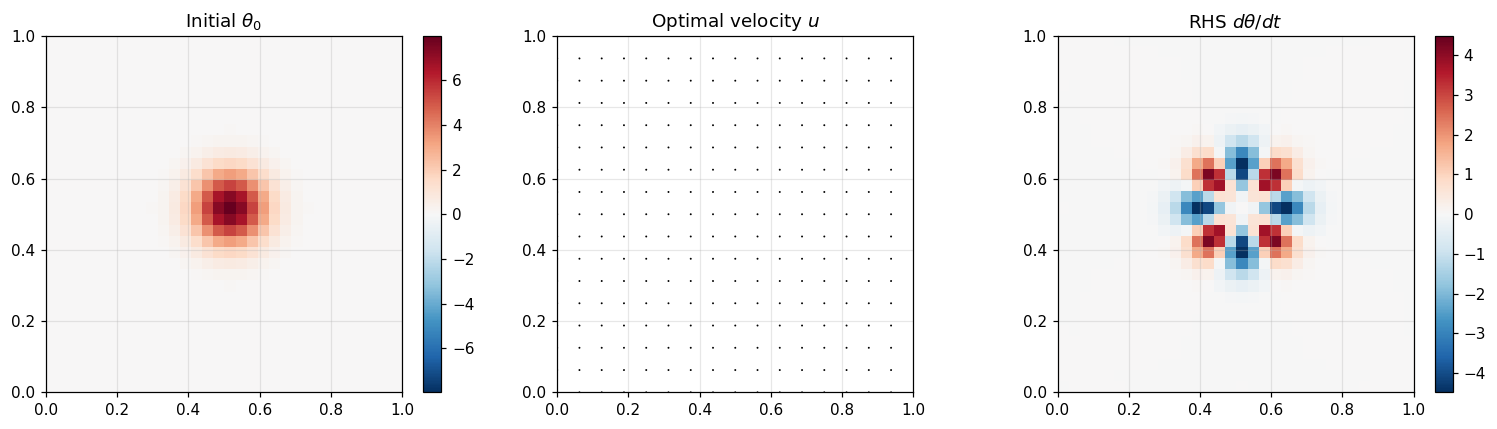

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

vt = np.abs(theta0).max()
im0 = axes[0].imshow(theta0, origin='lower', extent=[0,1,0,1], cmap='RdBu_r',
                     vmin=-vt, vmax=vt, aspect='equal')
axes[0].set_title('Initial $\\theta_0$'); plt.colorbar(im0, ax=axes[0], fraction=0.046)

step = 2
axes[1].quiver(xx[::step,::step], yy[::step,::step],
               ux[::step,::step], uy[::step,::step], scale=25, width=0.006)
axes[1].set_title('Optimal velocity $u$')
axes[1].set_aspect('equal'); axes[1].set_xlim(0,1); axes[1].set_ylim(0,1)

vr = np.abs(rhs).max()
im2 = axes[2].imshow(rhs, origin='lower', extent=[0,1,0,1], cmap='RdBu_r',
                     vmin=-vr, vmax=vr, aspect='equal')
axes[2].set_title('RHS $d\\theta/dt$'); plt.colorbar(im2, ax=axes[2], fraction=0.046)
plt.tight_layout(); plt.show()

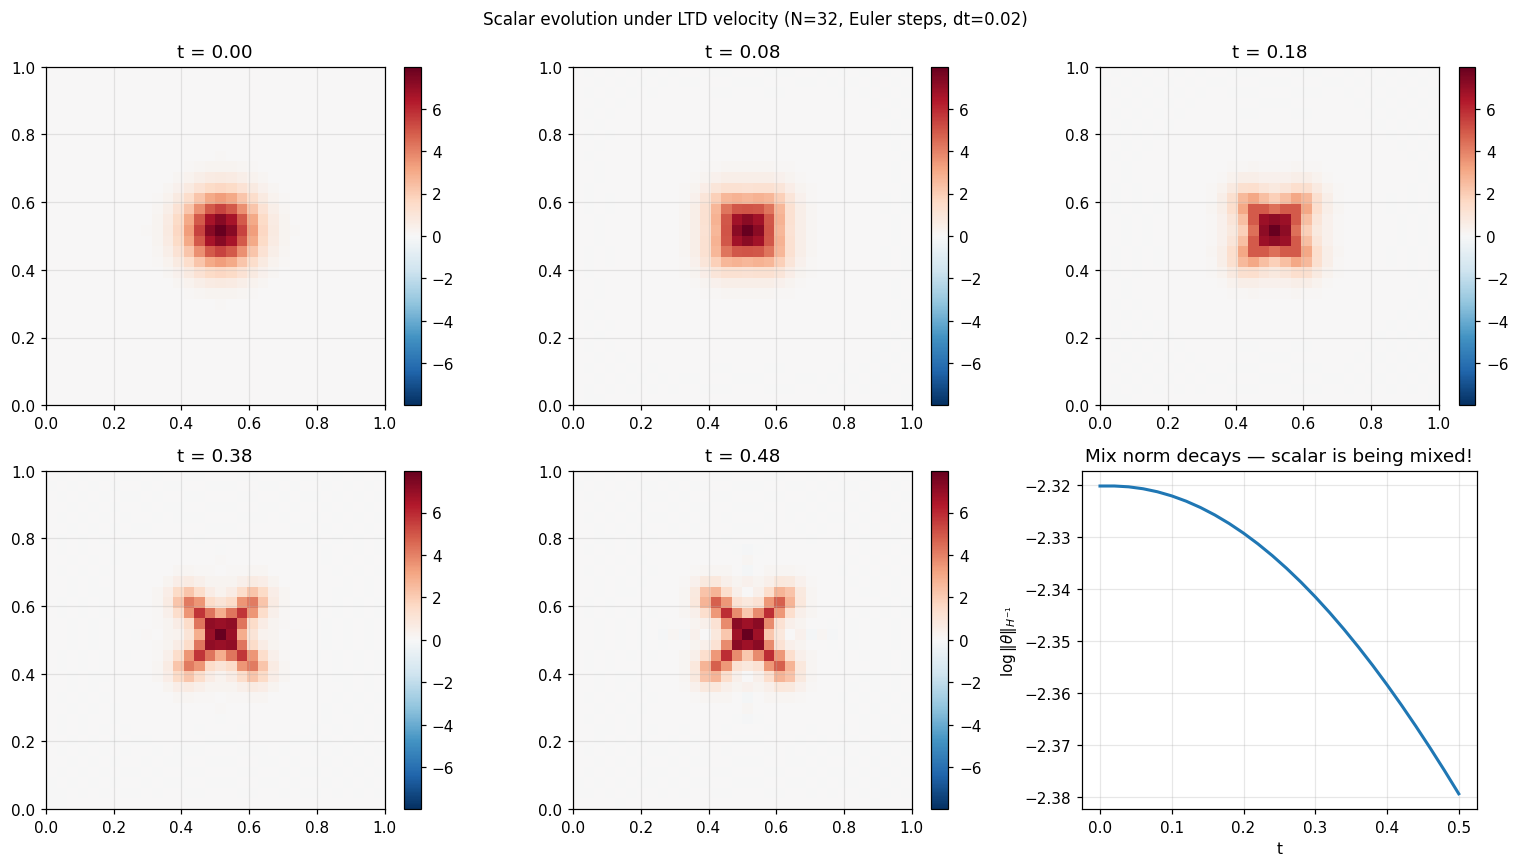

H^{-1} at t=0:    0.0983
H^{-1} at t=0.50: 0.0926  (decreased by 5.7%)


In [22]:
# Watch the mix norm decay as Euler time-stepping is applied
# (Real simulation uses RK45; this is just for illustration)
dt = 0.02; n_steps = 25; theta = theta0.copy()
h1s = [hm1_norm(theta, LAMBDA_INV2, N)]
snaps = [theta.copy()]

for si in range(n_steps):
    rhs_hat, _, _ = compute_rhs(theta, DEL_X, DEL_Y, LAP_INV2, N)
    theta = np.real(np.fft.ifft2(np.fft.fft2(theta) + dt*rhs_hat))
    h1s.append(hm1_norm(theta, LAMBDA_INV2, N))
    if si in [4, 9, 19, 24]:
        snaps.append(theta.copy())

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
times = [0, 4*dt, 9*dt, 19*dt, 24*dt]
vmax0 = np.abs(theta0).max()
for ax, snap, t in zip(axes.ravel()[:5], snaps, times):
    im = ax.imshow(snap, origin='lower', extent=[0,1,0,1], cmap='RdBu_r',
                   vmin=-vmax0, vmax=vmax0, aspect='equal')
    ax.set_title(f't = {t:.2f}'); plt.colorbar(im, ax=ax, fraction=0.046)

t_arr = np.arange(n_steps+1)*dt
axes[1,2].plot(t_arr, np.log(h1s), 'C0', lw=2)
axes[1,2].set_xlabel('t'); axes[1,2].set_ylabel('$\\log \\|\\theta\\|_{H^{-1}}$')
axes[1,2].set_title('Mix norm decays — scalar is being mixed!')

fig.suptitle(f'Scalar evolution under LTD velocity (N={N}, Euler steps, dt={dt})', fontsize=11)
plt.tight_layout(); plt.show()

print(f'H^{{-1}} at t=0:    {h1s[0]:.4f}')
print(f'H^{{-1}} at t={n_steps*dt:.2f}: {h1s[-1]:.4f}  (decreased by {100*(1-h1s[-1]/h1s[0]):.1f}%)')

---
## Summary

| Concept | What it is | Code |
|---|---|---|
| DFT | Decompose discrete signal into frequencies | `np.fft.fft2` |
| FFT | Fast $O(N\log N)$ algorithm for DFT | same function |
| Centred wavenumber | $k_\text{eff} = k - N\cdot\mathbf{1}[k>N/2]$ | `k - N*(k > N//2)` |
| Spectral derivative | Multiply $\hat f$ by $2\pi ik$ (Nyquist zeroed) | `DEL_X`, `DEL_Y` |
| Inverse Laplacian | Multiply $\hat f$ by $-1/(4\pi^2|k|^2)$ (DC zeroed) | `LAP_INV` |
| Parseval identity | $\|f\|_{L^2} = \|\hat f\|_{\ell^2}/N^2$ (2D) | norm computations |
| $H^{-1}$ mix norm | Weighted norm, small when well-mixed | `LAMBDA_INV` |
| Leray projection | Remove divergent part of a vector field | Step 2 of RHS |
| Pseudo-spectral | Products in physical space, operators in Fourier | RHS pipeline |
| RK45 | Adaptive-step 4/5 Runge–Kutta solver | `scipy.integrate.solve_ivp` |

**Continue to:** [01_operators_and_idata.ipynb](01_operators_and_idata.ipynb)

---
## Recommended Books

### Introductory
- **"A Student's Guide to Fourier Transforms"** — J.F. James (Cambridge, 3rd ed.)  
  Most accessible intro. Short chapters, physical intuition, minimal prerequisites.
- **"The Fourier Transform and Its Applications"** — R. Bracewell (McGraw-Hill, 3rd ed.)  
  Classic with excellent visualisations. Famous 'picket fence' picture of the DFT.
- **"Fourier Analysis: An Introduction"** — Stein & Shakarchi (Princeton, 2003)  
  More rigorous but very clear. Good for understanding *why* things work.

### Spectral and Numerical Methods
- **"Spectral Methods in MATLAB"** — L.N. Trefethen (SIAM, 2000) — *free PDF online*  
  Perfect companion to this project. 40 short programs. Very readable.
- **"Numerical Methods for Engineers"** — Chapra & Canale (McGraw-Hill)  
  Covers FFT, RK45, numerical differentiation at an introductory engineering level.
- **"A Practical Guide to Pseudospectral Methods"** — B. Fornberg (Cambridge)  
  Specifically about pseudo-spectral methods. Most thorough treatment of the subject.

### Online
- 3Blue1Brown: *"But What Is the Fourier Transform?"* — best visual intro (YouTube)
- 3Blue1Brown: *"But What Is a Fourier Series?"* — intuition for wave decomposition
- NumPy FFT documentation — exact conventions used by `np.fft.fft2`